# 🧠 Brain Tumor Segmentation Support System — SIC Capstone v3 (BraTS 2023)
### Pipeline Hoàn Chỉnh: EDA → Tiền Xử Lý Z-Score NPZ → Huấn Luyện 3D U-Net & Swin UNETR → Hậu Xử Lý → Đánh Giá → Trực Quan Hóa → Báo Cáo PDF

| Feature | Description |
|---|---|
| **Mục tiêu** | Phân đoạn tự động u não 3D (BraTS 2023) thành 3 vùng: WT, TC, ET |
| **Kiến trúc** | 3D U-Net Baseline & Swin UNETR (Transformer) |
| **Pipeline** | Tải Data Drive/Local, EDA chi tiết, Tiền xử lý Z-score NPZ, Huấn luyện (CosineAnnealingLR + Early Stopping), Hậu xử lý CCA, Đánh giá (Dice/IoU/Volume), Translucent Overlay Visualizer, Xuất PDF & ONNX/TorchScript |
| **Phiên bản** | v3 (Tối ưu hóa Production & Chuẩn PRD Capstone 2026) |

## 1. Cài Đặt Môi Trường, Tải Dữ Liệu & Mount Google Drive
Cài đặt các thư viện phụ thuộc (`monai`, `nibabel`, `gdown`, `fpdf2`, `torchinfo`, `onnx`, `onnxscript`, v.v.) và tự động tải dữ liệu từ Google Drive nếu chưa có sẵn trên máy.

In [10]:
!pip install -q monai nibabel fpdf2 matplotlib torchinfo tqdm scikit-learn pandas scipy gdown onnx onnxscript

import os
import glob
import time
import json
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.dataloader import default_collate
from tqdm.auto import tqdm
from scipy.ndimage import binary_dilation, label as scipy_label
from sklearn.model_selection import train_test_split

import monai
from monai.transforms import (
    Compose, EnsureTyped, RandCropByPosNegLabeld, RandFlipd,
    RandRotate90d, RandScaleIntensityd, RandShiftIntensityd, RandGaussianNoised
)
from monai.networks.nets import UNet, SwinUNETR
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from torchinfo import summary
from fpdf import FPDF
from datetime import datetime

# 1. Mount Google Drive nếu chạy trên Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Mounted Google Drive thành công!")
except Exception:
    print("ℹ️ Đang chạy trên môi trường Cục bộ (Local).")

ℹ️ Đang chạy trên môi trường Cục bộ (Local).



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Cấu Hình Tập Trung (CFG) & Tự Động Quét/Tải Dữ Liệu
Quản lý siêu tham số qua class `CFG`, tự động quét các đường dẫn dữ liệu cục bộ hoặc tải từ Google Drive Folder ID `1tM-M_Xxw6q-pbhdTwkFqaatBZXqLc4B5`.

In [11]:
class CFG:
    seed = 42
    modalities = ['t1n', 't1c', 't2w', 't2f']
    in_channels = 4
    out_channels = 4  # 0: Background, 1: NCR/NET, 2: ED, 3: ET
    classes = ['Background', 'NCR/NET', 'ED', 'ET']
    target_shape = (240, 240, 155)
    patch_size = (96, 96, 96)

    val_split = 0.2
    val_subset_size = 2   # Dataset test 6 cases -> val 1-2 cases
    batch_size = 2
    num_samples = 2
    num_workers = 0       # Windows: đặt 0 để tránh lỗi multiprocessing

    learning_rate = 2e-4
    weight_decay = 1e-4
    max_epochs = 20
    val_interval = 2
    early_stopping_patience = 5  # Dừng sớm nếu không cải thiện sau 5 lần val

    sw_batch_size = 2
    sw_overlap = 0.5
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    monai.utils.misc.set_determinism(seed=seed)

set_seed(CFG.seed)
print(f"🖥️ Thiết bị sử dụng: {CFG.device}")
if torch.cuda.is_available():
    print(f"⚡ GPU: {torch.cuda.get_device_name(0)}")

# ===== Quét đường dẫn dữ liệu =====
RAW_DATA_CANDIDATES = [
    r't:\AI SAMSUNG\DoAn\Brain-Tumor-Segmentation-Support-System-main\Datasets\synthetic_brats',
    r't:/AI SAMSUNG/DoAn/Brain-Tumor-Segmentation-Support-System-main/Datasets/synthetic_brats',
    'Datasets/synthetic_brats',
    '../DoAn/Brain-Tumor-Segmentation-Support-System-main/Datasets/synthetic_brats',
    './data/raw/synthetic_brats',
    './data/synthetic_brats',
    '/content/drive/MyDrive/synthetic_brats',
    '/content/drive/MyDrive/BraTS2023_Raw',
    './data/raw'
]

DATA_ROOT = next((p for p in RAW_DATA_CANDIDATES if os.path.exists(p) and len(glob.glob(os.path.join(p, '*'))) > 0), None)

# Nếu chưa có data cục bộ, tự động tải từ Google Drive qua gdown
DRIVE_FOLDER_ID = "1tM-M_Xxw6q-pbhdTwkFqaatBZXqLc4B5"
if DATA_ROOT is None:
    print(f"🌐 Không tìm thấy dữ liệu cục bộ. Đang tải tự động từ Google Drive ({DRIVE_FOLDER_ID})...")
    download_target = "./data/raw/synthetic_brats"
    os.makedirs(download_target, exist_ok=True)
    try:
        import gdown
        gdown.download_folder(id=DRIVE_FOLDER_ID, output=download_target, quiet=False, use_cookies=False)
        if os.path.exists(download_target) and len(glob.glob(os.path.join(download_target, '*'))) > 0:
            DATA_ROOT = download_target
            print(f"✅ Tải dữ liệu từ Google Drive thành công về: {DATA_ROOT}")
    except Exception as e:
        print(f"⚠️ Không thể tải tự động từ Drive: {e}")

# Đặt PREPROCESSED_DIR thông minh cùng cấp với DATA_ROOT hoặc thư mục project
if DATA_ROOT is not None:
    PREPROCESSED_DIR = os.path.join(os.path.dirname(os.path.abspath(DATA_ROOT)), 'processed_npz')
else:
    PREPROCESSED_DIR = './data/processed_npz'

CHECKPOINT_DIR = './checkpoints'
MODEL_DIR = './models'

os.makedirs(PREPROCESSED_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"📁 Đường dẫn được cấu hình:")
print(f"  - DATA_ROOT (Raw): {DATA_ROOT}")
print(f"  - PREPROCESSED_DIR: {PREPROCESSED_DIR}")
print(f"  - CHECKPOINT_DIR: {CHECKPOINT_DIR}")
print(f"  - MODEL_DIR: {MODEL_DIR}")

🖥️ Thiết bị sử dụng: cpu
📁 Đường dẫn được cấu hình:
  - DATA_ROOT (Raw): t:\AI SAMSUNG\DoAn\Brain-Tumor-Segmentation-Support-System-main\Datasets\synthetic_brats
  - PREPROCESSED_DIR: t:\AI SAMSUNG\DoAn\Brain-Tumor-Segmentation-Support-System-main\Datasets\processed_npz
  - CHECKPOINT_DIR: ./checkpoints
  - MODEL_DIR: ./models


## 3. Pipeline Tiền Xử Lý NPZ Cache & Chuẩn Hóa Cường Độ (Z-Score)
Đọc dữ liệu NIfTI, cắt ngưỡng Percentile 0.5% - 99.5%, chuẩn hóa Z-score trên vùng mô não (Brain Mask), remap nhãn chuẩn BraTS và nén lưu dưới dạng `.npz` để tăng tốc độ I/O.

In [12]:
# BraTS 2023 Labels gốc: 0=BG, 1=NCR/NET, 2=ED, 4=ET (KHÔNG có label 3)
# Remap chuẩn: ET(4) → 3 để out_channels=4 (0,1,2,3)
LABEL_REMAP = {0: 0, 1: 1, 2: 2, 4: 3}

def load_and_normalize_case_nifti(case_path):
    vols = []
    for mod in CFG.modalities:
        fpath = glob.glob(os.path.join(case_path, f"*{mod}*.nii.gz"))
        if not fpath:
            return None
        arr = nib.load(fpath[0]).get_fdata(dtype=np.float32)

        # Z-score Normalization theo từng vùng não (Brain Mask)
        brain_mask = arr > 0
        if brain_mask.any():
            vals = arr[brain_mask]
            p_low, p_high = np.percentile(vals, [0.5, 99.5])
            arr = np.clip(arr, p_low, p_high)
            mean_val, std_val = arr[brain_mask].mean(), arr[brain_mask].std()
            if std_val > 1e-6:
                arr = (arr - mean_val) / std_val
            arr[~brain_mask] = 0.0
        vols.append(arr)

    seg_path = glob.glob(os.path.join(case_path, f"*seg*.nii.gz"))
    if not seg_path:
        return None
    
    # Đọc mask phân đoạn (load float32 sau đó cast int16 để tương thích mọi phiên bản nibabel)
    raw_seg = nib.load(seg_path[0]).get_fdata(dtype=np.float32).astype(np.int16)

    seg = np.zeros_like(raw_seg, dtype=np.int16)
    for k, v in LABEL_REMAP.items():
        seg[raw_seg == k] = v

    img = np.stack(vols, axis=0).astype(np.float32)  # (4, H, W, D)
    return img, seg

def preprocess_single_case(case_dir, out_path):
    res = load_and_normalize_case_nifti(case_dir)
    if res is None:
        return False
    img, seg = res
    np.savez_compressed(out_path, image=img, label=seg)
    return True

def ensure_preprocessed_npz():
    if os.path.exists(PREPROCESSED_DIR):
        npz_files = glob.glob(os.path.join(PREPROCESSED_DIR, "*.npz"))
        if len(npz_files) > 0:
            print(f"✅ Tìm thấy {len(npz_files)} file NPZ đã chuẩn hóa Z-score. Sử dụng NPZ Cache.")
            return sorted([os.path.basename(f).replace('.npz', '') for f in npz_files])

    if DATA_ROOT is None or not os.path.exists(DATA_ROOT):
        print("❌ Không tìm thấy dữ liệu Raw hoặc NPZ!")
        return []

    case_dirs = sorted([d for d in glob.glob(os.path.join(DATA_ROOT, "*")) if os.path.isdir(d)])
    print(f"⏳ Tìm thấy {len(case_dirs)} cases raw tại: {DATA_ROOT}")
    print(f"   Tiến hành Z-score normalization và lưu NPZ vào: {PREPROCESSED_DIR}")

    all_cases = []
    for c_dir in tqdm(case_dirs, desc="Preprocess NPZ"):
        cid = os.path.basename(c_dir)
        out_p = os.path.join(PREPROCESSED_DIR, f"{cid}.npz")
        if not os.path.exists(out_p):
            ok = preprocess_single_case(c_dir, out_p)
            if not ok:
                print(f"   ⚠️ Bỏ qua {cid}: không tìm thấy đủ file các chuỗi xung MRI")
                continue
        all_cases.append(cid)

    return all_cases

all_case_ids = ensure_preprocessed_npz()

# Serialize case list để tránh mất khi restart kernel
_cache_ids_path = os.path.join(CHECKPOINT_DIR, 'case_ids.json')
if len(all_case_ids) > 0:
    with open(_cache_ids_path, 'w') as _f:
        json.dump(all_case_ids, _f)
elif os.path.exists(_cache_ids_path):
    with open(_cache_ids_path) as _f:
        all_case_ids = json.load(_f)
    print(f"✅ Đọc từ cache: {len(all_case_ids)} cases")

print(f"✅ Tổng số cases sẵn sàng: {len(all_case_ids)}")
if len(all_case_ids) > 0:
    print(f"   Danh sách cases: {all_case_ids}")

✅ Tìm thấy 6 file NPZ đã chuẩn hóa Z-score. Sử dụng NPZ Cache.
✅ Tổng số cases sẵn sàng: 6
   Danh sách cases: ['BraTS-GLI-00001-000', 'BraTS-GLI-00002-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-00004-000', 'BraTS-GLI-00005-000', 'BraTS-GLI-00006-000']


## 4. Khám Phá Dữ Liệu (EDA) — Data Understanding
### 4.1. Structure inspection & label inventory

In [13]:
def eda_structure(case_id):
    print(f"🔍 Kiểm tra cấu trúc case: {case_id}")
    npz_path = os.path.join(PREPROCESSED_DIR, f"{case_id}.npz")
    if os.path.exists(npz_path):
        data = np.load(npz_path)
        img, seg = data['image'], data['label']
        print(f"  - Shape Image: {img.shape}, Type: {img.dtype}, Min: {img.min():.2f}, Max: {img.max():.2f}")
        print(f"  - Shape Label: {seg.shape}, Type: {seg.dtype}, Unique Labels: {np.unique(seg)}")

        unique, counts = np.unique(seg, return_counts=True)
        total = seg.size
        print("  - Label Inventory:")
        for u, c in zip(unique, counts):
            lbl_name = CFG.classes[u] if u < len(CFG.classes) else f"Label {u}"
            print(f"      {lbl_name} (Label {u}): {c:,} voxels ({c/total*100:.2f}%)")
    else:
        print("  - File NPZ không tồn tại!")

if len(all_case_ids) > 0:
    eda_structure(all_case_ids[0])

🔍 Kiểm tra cấu trúc case: BraTS-GLI-00001-000
  - Shape Image: (4, 64, 64, 64), Type: float32, Min: -2.59, Max: 4.26
  - Shape Label: (64, 64, 64), Type: int16, Unique Labels: [0 1 2]
  - Label Inventory:
      Background (Label 0): 245,324 voxels (93.58%)
      NCR/NET (Label 1): 1,852 voxels (0.71%)
      ED (Label 2): 14,968 voxels (5.71%)


### 4.2. Intensity distributions & class statistics

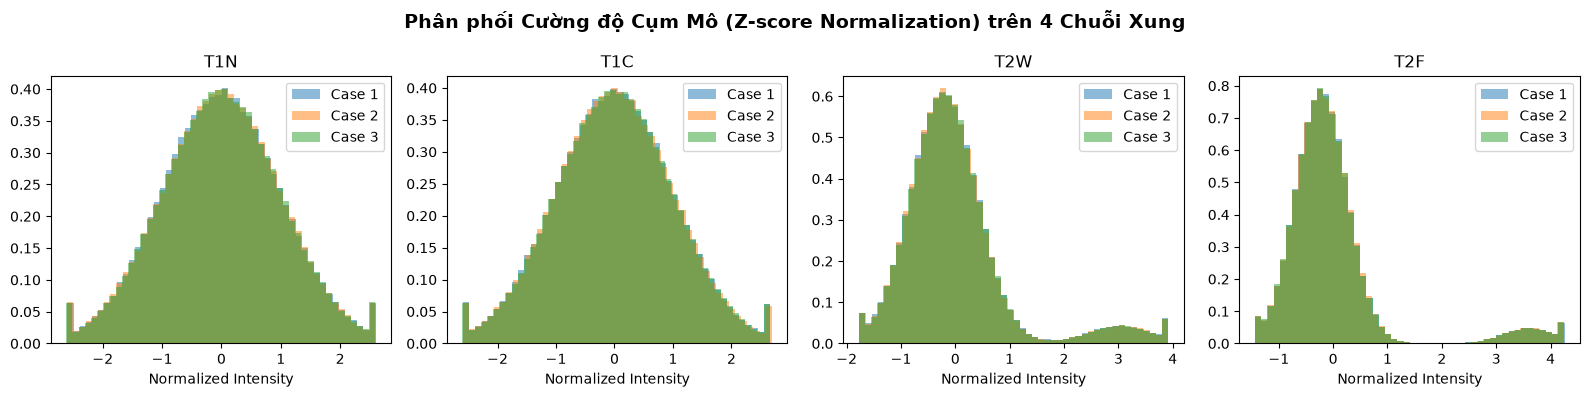

In [14]:
def eda_intensity_dist(case_ids, num_samples=3):
    if len(case_ids) == 0:
        return
    samples = np.random.choice(case_ids, min(num_samples, len(case_ids)), replace=False)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for i, cid in enumerate(samples):
        npz_path = os.path.join(PREPROCESSED_DIR, f"{cid}.npz")
        data = np.load(npz_path)
        img = data['image']  # (4, H, W, D)

        for c in range(4):
            vols = img[c].flatten()
            vols = vols[vols != 0]  # bỏ background 0
            axes[c].hist(vols, bins=50, alpha=0.5, label=f"Case {i+1}", density=True)
            axes[c].set_title(CFG.modalities[c].upper())
            axes[c].set_xlabel("Normalized Intensity")
            axes[c].legend()

    plt.suptitle("Phân phối Cường độ Cụm Mô (Z-score Normalization) trên 4 Chuỗi Xung", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(all_case_ids) > 0:
    eda_intensity_dist(all_case_ids)

### 4.3. Visualizing 4 modalities & GT mask overlay on axial slice

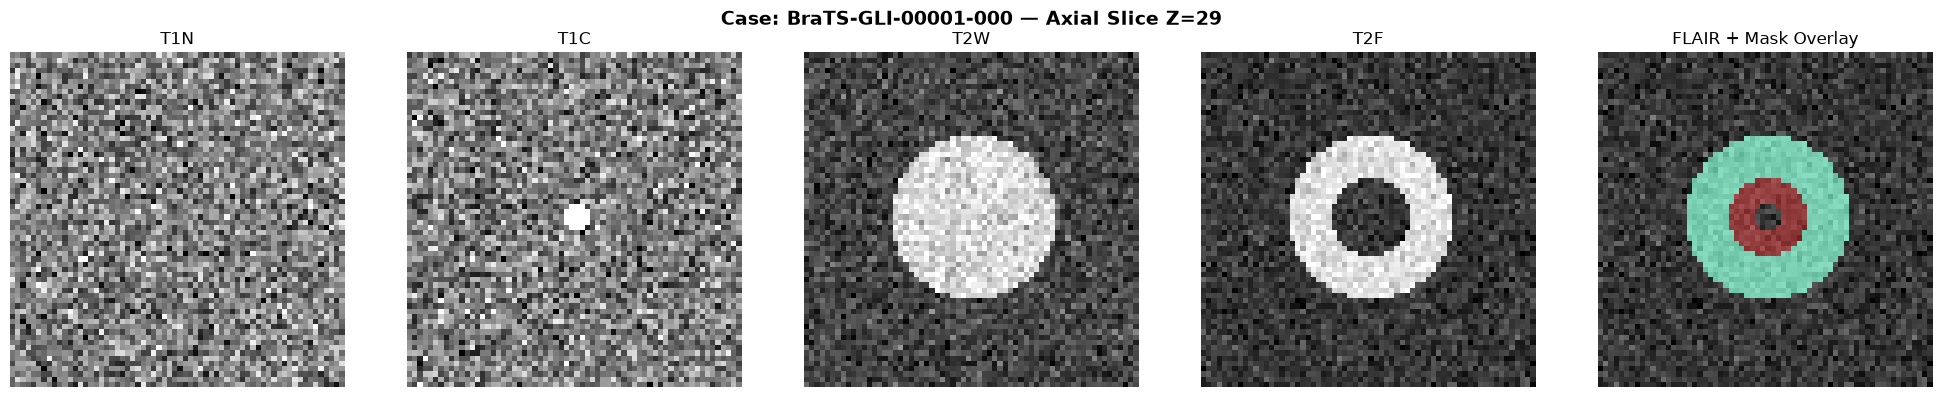

In [15]:
def visualize_slice(case_id):
    npz_path = os.path.join(PREPROCESSED_DIR, f"{case_id}.npz")
    if not os.path.exists(npz_path):
        return
    data = np.load(npz_path)
    img, seg = data['image'], data['label']

    # Tìm lát cắt axial có diện tích khối u lớn nhất
    slice_counts = np.sum(seg > 0, axis=(0, 1))
    z = np.argmax(slice_counts) if slice_counts.max() > 0 else seg.shape[2] // 2

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for c in range(4):
        axes[c].imshow(img[c, :, :, z].T, cmap='gray', origin='lower')
        axes[c].set_title(CFG.modalities[c].upper())
        axes[c].axis('off')

    cmap_seg = ListedColormap(['none', '#EF4444', '#10B981', '#F59E0B'])
    axes[4].imshow(img[3, :, :, z].T, cmap='gray', origin='lower')
    axes[4].imshow(seg[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')
    axes[4].set_title('FLAIR + Mask Overlay')
    axes[4].axis('off')

    plt.suptitle(f"Case: {case_id} — Axial Slice Z={z}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(all_case_ids) > 0:
    visualize_slice(all_case_ids[0])

## 5. Phân Chia Dataset & Khởi Tạo DataLoaders
Phân chia Train/Validation set và khởi tạo PyTorch Dataset & MONAI Augmentation DataLoaders.

In [16]:
class PreprocessedBraTSDataset3D(Dataset):
    def __init__(self, case_ids, transform=None):
        self.case_ids = case_ids
        self.transform = transform

    def __len__(self):
        return len(self.case_ids)

    def __getitem__(self, idx):
        npz_path = os.path.join(PREPROCESSED_DIR, f"{self.case_ids[idx]}.npz")
        data = np.load(npz_path)
        img = data['image'].astype(np.float32)
        lbl = data['label'].astype(np.int64)
        if lbl.ndim == 3:
            lbl = np.expand_dims(lbl, 0)

        item = {'image': img, 'label': lbl, 'case_id': self.case_ids[idx]}
        if self.transform:
            item = self.transform(item)
        return item

if len(all_case_ids) > 0:
    # Với dataset nhỏ (6 cases): đảm bảo có ít nhất 1 case mỗi split
    _val_split = CFG.val_split if len(all_case_ids) >= 5 else 1/len(all_case_ids)
    train_cases, val_cases = train_test_split(all_case_ids, test_size=_val_split, random_state=CFG.seed)
    val_cases_fast = val_cases[:max(1, CFG.val_subset_size)]

    train_transforms = Compose([
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=CFG.patch_size,
            pos=1,
            neg=1,
            num_samples=CFG.num_samples,
            allow_smaller=True
        ),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
        RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
        RandGaussianNoised(keys="image", prob=0.3, mean=0.0, std=0.05),
        EnsureTyped(keys=["image", "label"], device=torch.device('cpu'), track_meta=False)
    ])
    
    val_transforms = Compose([
        EnsureTyped(keys=["image", "label"], device=torch.device('cpu'), track_meta=False)
    ])

    train_ds = PreprocessedBraTSDataset3D(train_cases, transform=train_transforms)
    val_ds_fast = PreprocessedBraTSDataset3D(val_cases_fast, transform=val_transforms)
    val_ds_full = PreprocessedBraTSDataset3D(val_cases, transform=val_transforms)

    def collate_fn_list(batch):
        """Flatten list-of-patches từ RandCropByPosNegLabeld rồi collate tensor."""
        flat_batch = []
        for item in batch:
            if isinstance(item, list):
                flat_batch.extend(item)
            else:
                flat_batch.append(item)
        # Loại bỏ case_id (string) trước khi collate tensor
        tensor_batch = [{k: v for k, v in b.items() if k != 'case_id'} for b in flat_batch]
        return default_collate(tensor_batch)

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                              num_workers=CFG.num_workers, collate_fn=collate_fn_list)
    val_loader_fast = DataLoader(val_ds_fast, batch_size=1, num_workers=0)
    val_loader_full = DataLoader(val_ds_full, batch_size=1, num_workers=0)

    print(f"✅ Khởi tạo DataLoader thành công!")
    print(f"  - Train cases ({len(train_cases)}): {train_cases}")
    print(f"  - Val cases Fast ({len(val_cases_fast)}): {val_cases_fast}")
    print(f"  - Val cases Full ({len(val_cases)}): {val_cases}")

✅ Khởi tạo DataLoader thành công!
  - Train cases (4): ['BraTS-GLI-00006-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-00005-000', 'BraTS-GLI-00004-000']
  - Val cases Fast (2): ['BraTS-GLI-00001-000', 'BraTS-GLI-00002-000']
  - Val cases Full (2): ['BraTS-GLI-00001-000', 'BraTS-GLI-00002-000']


## 6. Hàm Tiện Ích Đánh Giá (Metrics) & Hậu Xử Lý (CCA)
Tính toán chỉ số Dice/IoU chuẩn BraTS (xử lý chính xác trường hợp 0/0 = 1.0), quy đổi thể tích u (cm³) và hậu xử lý lọc nhiễu thành phần liên thông (Connected Component Analysis - CCA).

In [17]:
def compute_brats_dice(pred, target):
    """Calculates Dice score for BraTS sub-regions: WT (1,2,3), TC (1,3), ET (3)."""
    p = pred.squeeze().cpu().numpy() if isinstance(pred, torch.Tensor) else np.squeeze(pred)
    t = target.squeeze().cpu().numpy() if isinstance(target, torch.Tensor) else np.squeeze(target)

    def calculate_dice(p_binary, t_binary):
        inter = np.sum(p_binary * t_binary)
        total = np.sum(p_binary) + np.sum(t_binary)
        if total == 0:
            return 1.0  # Cả GT và Pred không có u -> 100% đúng
        return float(2.0 * inter / (total + 1e-8))

    wt_p, wt_t = (p >= 1).astype(np.float32), (t >= 1).astype(np.float32)
    tc_p, tc_t = ((p == 1) | (p == 3)).astype(np.float32), ((t == 1) | (t == 3)).astype(np.float32)
    et_p, et_t = (p == 3).astype(np.float32), (t == 3).astype(np.float32)

    return calculate_dice(wt_p, wt_t), calculate_dice(tc_p, tc_t), calculate_dice(et_p, et_t)

def compute_comprehensive_metrics(pred, target):
    """Calculates Dice and IoU metrics for WT, TC, ET sub-regions."""
    wt_d, tc_d, et_d = compute_brats_dice(pred, target)

    p = pred.squeeze().cpu().numpy() if isinstance(pred, torch.Tensor) else np.squeeze(pred)
    t = target.squeeze().cpu().numpy() if isinstance(target, torch.Tensor) else np.squeeze(target)
    
    def calculate_iou(p_b, t_b):
        inter = np.sum(p_b * t_b)
        union = np.sum(p_b) + np.sum(t_b) - inter
        if union == 0: return 1.0
        return float(inter / (union + 1e-8))

    wt_p, wt_t = (p >= 1).astype(np.float32), (t >= 1).astype(np.float32)
    tc_p, tc_t = ((p == 1) | (p == 3)).astype(np.float32), ((t == 1) | (t == 3)).astype(np.float32)
    et_p, et_t = (p == 3).astype(np.float32), (t == 3).astype(np.float32)

    return {
        'Dice_WT': wt_d, 'Dice_TC': tc_d, 'Dice_ET': et_d, 'Mean_Dice': (wt_d + tc_d + et_d) / 3.0,
        'IoU_WT': calculate_iou(wt_p, wt_t), 'IoU_TC': calculate_iou(tc_p, tc_t),
        'IoU_ET': calculate_iou(et_p, et_t),
        'Mean_IoU': (calculate_iou(wt_p, wt_t) + calculate_iou(tc_p, tc_t) + calculate_iou(et_p, et_t)) / 3.0
    }

def compute_tumor_volume(mask, spacing=(1.0, 1.0, 1.0)):
    """Tính thể tích khối u (cm³). Hỗ trợ cả torch.Tensor lẫn numpy array."""
    m = mask.squeeze().cpu().numpy() if isinstance(mask, torch.Tensor) else np.squeeze(mask)
    voxel_vol = spacing[0] * spacing[1] * spacing[2] / 1000.0  # mm³ → cm³

    wt = float((m > 0).sum() * voxel_vol)
    tc = float(((m == 1) | (m == 3)).sum() * voxel_vol)
    et = float((m == 3).sum() * voxel_vol)
    return wt, tc, et

def postprocess_connected_components(pred_mask, min_size=50):
    """Khử nhiễu đốm nhỏ rác bằng Connected Component Analysis."""
    cleaned = np.copy(pred_mask)
    for c in [1, 2, 3]:
        binary_c = (pred_mask == c)
        labeled, num_features = scipy_label(binary_c)
        for i in range(1, num_features + 1):
            if (labeled == i).sum() < min_size:
                cleaned[labeled == i] = 0
    return cleaned

## 7. Huấn Luyện Mô Hình 1: 3D U-Net Baseline

In [18]:
def train_model(model, loader_train, loader_val, max_epochs, model_name="UNet",
                patience=None):
    """Train với CosineAnnealingLR scheduler và Early Stopping."""
    if patience is None:
        patience = CFG.early_stopping_patience

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
    # CosineAnnealingLR: giảm LR mượt từ lr_max → eta_min theo hàm cosine
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)
    loss_function = DiceCELoss(to_onehot_y=True, softmax=True, include_background=True)
    use_cuda = CFG.device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)

    history = {'train_loss': [], 'val_dice': [], 'val_wt': [], 'val_tc': [], 'val_et': []}
    best_dice = 0.0
    patience_counter = 0
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{model_name}.pth")
    hist_path = os.path.join(CHECKPOINT_DIR, f"history_{model_name}.json")

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        step = 0
        
        pbar = tqdm(loader_train, desc=f"Epoch {epoch+1}/{max_epochs} ({model_name})")
        for batch_data in pbar:
            step += 1
            inputs = batch_data["image"].to(CFG.device)
            labels = batch_data["label"].to(CFG.device)

            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_cuda):
                outputs = model(inputs)
                loss = loss_function(outputs, labels)

            if use_cuda:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}",
                              'lr': f"{scheduler.get_last_lr()[0]:.2e}"})

        epoch_loss /= max(1, step)
        history['train_loss'].append(epoch_loss)
        scheduler.step()  # Cập nhật LR sau mỗi epoch

        if (epoch + 1) % CFG.val_interval == 0:
            model.eval()
            wt_list, tc_list, et_list = [], [], []
            
            with torch.no_grad():
                for val_data in loader_val:
                    inputs = val_data["image"].to(CFG.device)
                    labels = val_data["label"].to(CFG.device)

                    with torch.amp.autocast('cuda', enabled=use_cuda):
                        outputs = sliding_window_inference(
                            inputs, CFG.patch_size, CFG.sw_batch_size, model, overlap=CFG.sw_overlap
                        )

                    preds = torch.argmax(outputs, dim=1, keepdim=True)
                    wt, tc, et = compute_brats_dice(preds, labels)
                    wt_list.append(wt)
                    tc_list.append(tc)
                    et_list.append(et)

            m_wt, m_tc, m_et = np.mean(wt_list), np.mean(tc_list), np.mean(et_list)
            m_dice = (m_wt + m_tc + m_et) / 3.0
            
            history['val_wt'].append(float(m_wt))
            history['val_tc'].append(float(m_tc))
            history['val_et'].append(float(m_et))
            history['val_dice'].append(float(m_dice))

            print(f"🏆 [Val] Dice: {m_dice:.4f} | WT: {m_wt:.4f} | TC: {m_tc:.4f} | ET: {m_et:.4f}")

            if m_dice > best_dice:
                best_dice = m_dice
                patience_counter = 0
                torch.save(model.state_dict(), best_ckpt_path)
                print(f"⭐ Lưu checkpoint tốt nhất: {best_ckpt_path} ({best_dice:.4f})")
            else:
                patience_counter += 1
                print(f"⏳ Early Stopping patience: {patience_counter}/{patience}")
                if patience_counter >= patience:
                    print(f"🛑 Early Stopping triggered tại epoch {epoch+1}!")
                    break

        # Serialize history sau mỗi epoch (tránh mất dữ liệu khi crash)
        with open(hist_path, 'w') as hf:
            json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, hf, indent=2)

    return history, best_dice

if len(all_case_ids) > 0:
    unet_model = UNet(
        spatial_dims=3,
        in_channels=CFG.in_channels,
        out_channels=CFG.out_channels,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
        norm='batch',
        dropout=0.1
    ).to(CFG.device)

    total_params = sum(p.numel() for p in unet_model.parameters() if p.requires_grad)
    print(f"📐 3D U-Net — Trainable Parameters: {total_params:,}")

    print("🚀 Bắt đầu huấn luyện 3D U-Net Baseline...")
    unet_hist, unet_best = train_model(unet_model, train_loader, val_loader_fast, CFG.max_epochs, "UNet")

📐 3D U-Net — Trainable Parameters: 4,813,569
🚀 Bắt đầu huấn luyện 3D U-Net Baseline...


Epoch 1/20 (UNet):   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 (UNet):   0%|          | 0/2 [00:00<?, ?it/s]

🏆 [Val] Dice: 0.0501 | WT: 0.1309 | TC: 0.0195 | ET: 0.0000
⭐ Lưu checkpoint tốt nhất: ./checkpoints\best_UNet.pth (0.0501)


Epoch 3/20 (UNet):   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 18/20 (UNet):   0%|          | 0/2 [00:00<?, ?it/s]

🏆 [Val] Dice: 0.1032 | WT: 0.2930 | TC: 0.0165 | ET: 0.0000
⭐ Lưu checkpoint tốt nhất: ./checkpoints\best_UNet.pth (0.1032)


Epoch 19/20 (UNet):   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 (UNet):   0%|          | 0/2 [00:00<?, ?it/s]

🏆 [Val] Dice: 0.1058 | WT: 0.3003 | TC: 0.0172 | ET: 0.0000
⭐ Lưu checkpoint tốt nhất: ./checkpoints\best_UNet.pth (0.1058)


## 8. Huấn Luyện Mô Hình 2: Swin UNETR (Transformer)

In [19]:
if len(all_case_ids) > 0:
    import inspect
    # Cảnh báo nếu chạy CPU (Swin UNETR rất nặng)
    if CFG.device.type == 'cpu':
        print("⚠️  CẢNH BÁO: Swin UNETR feature_size=48 rất nặng trên CPU. Training có thể mất nhiều thời gian.")
        print("   💡 Tự động chọn feature_size=24 để chạy ổn định trên CPU.")

    # Tự động giảm feature_size khi dùng CPU để tránh OOM
    _feature_size = 48 if CFG.device.type == 'cuda' else 24

    swin_kwargs = {
        'in_channels': CFG.in_channels,
        'out_channels': CFG.out_channels,
        'feature_size': _feature_size,
        'use_checkpoint': True,
    }
    # Tự động tương thích linh hoạt mọi phiên bản MONAI
    _sig = inspect.signature(SwinUNETR.__init__)
    if 'img_size' in _sig.parameters:
        swin_kwargs['img_size'] = CFG.patch_size
    if 'spatial_dims' in _sig.parameters:
        swin_kwargs['spatial_dims'] = 3

    swin_model = SwinUNETR(**swin_kwargs).to(CFG.device)

    total_params_swin = sum(p.numel() for p in swin_model.parameters() if p.requires_grad)
    print(f"📐 Swin UNETR (feature_size={_feature_size}) — Trainable Parameters: {total_params_swin:,}")

    print("🚀 Bắt đầu huấn luyện Swin UNETR...")
    swin_hist, swin_best = train_model(swin_model, train_loader, val_loader_fast, CFG.max_epochs, "Swin")

⚠️  CẢNH BÁO: Swin UNETR feature_size=48 rất nặng trên CPU. Training có thể mất nhiều thời gian.
   💡 Tự động chọn feature_size=24 để chạy ổn định trên CPU.
📐 Swin UNETR (feature_size=24) — Trainable Parameters: 15,705,646
🚀 Bắt đầu huấn luyện Swin UNETR...


Epoch 1/20 (Swin):   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 (Swin):   0%|          | 0/2 [00:00<?, ?it/s]

🏆 [Val] Dice: 0.0666 | WT: 0.1775 | TC: 0.0224 | ET: 0.0000
⭐ Lưu checkpoint tốt nhất: ./checkpoints\best_Swin.pth (0.0666)


Epoch 3/20 (Swin):   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 18/20 (Swin):   0%|          | 0/2 [00:00<?, ?it/s]

🏆 [Val] Dice: 0.1170 | WT: 0.3278 | TC: 0.0231 | ET: 0.0000
⭐ Lưu checkpoint tốt nhất: ./checkpoints\best_Swin.pth (0.1170)


Epoch 19/20 (Swin):   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 (Swin):   0%|          | 0/2 [00:00<?, ?it/s]

🏆 [Val] Dice: 0.1172 | WT: 0.3284 | TC: 0.0232 | ET: 0.0000
⭐ Lưu checkpoint tốt nhất: ./checkpoints\best_Swin.pth (0.1172)


## 9. So Sánh Hiệu Năng & Đồ Thị Huấn Luyện

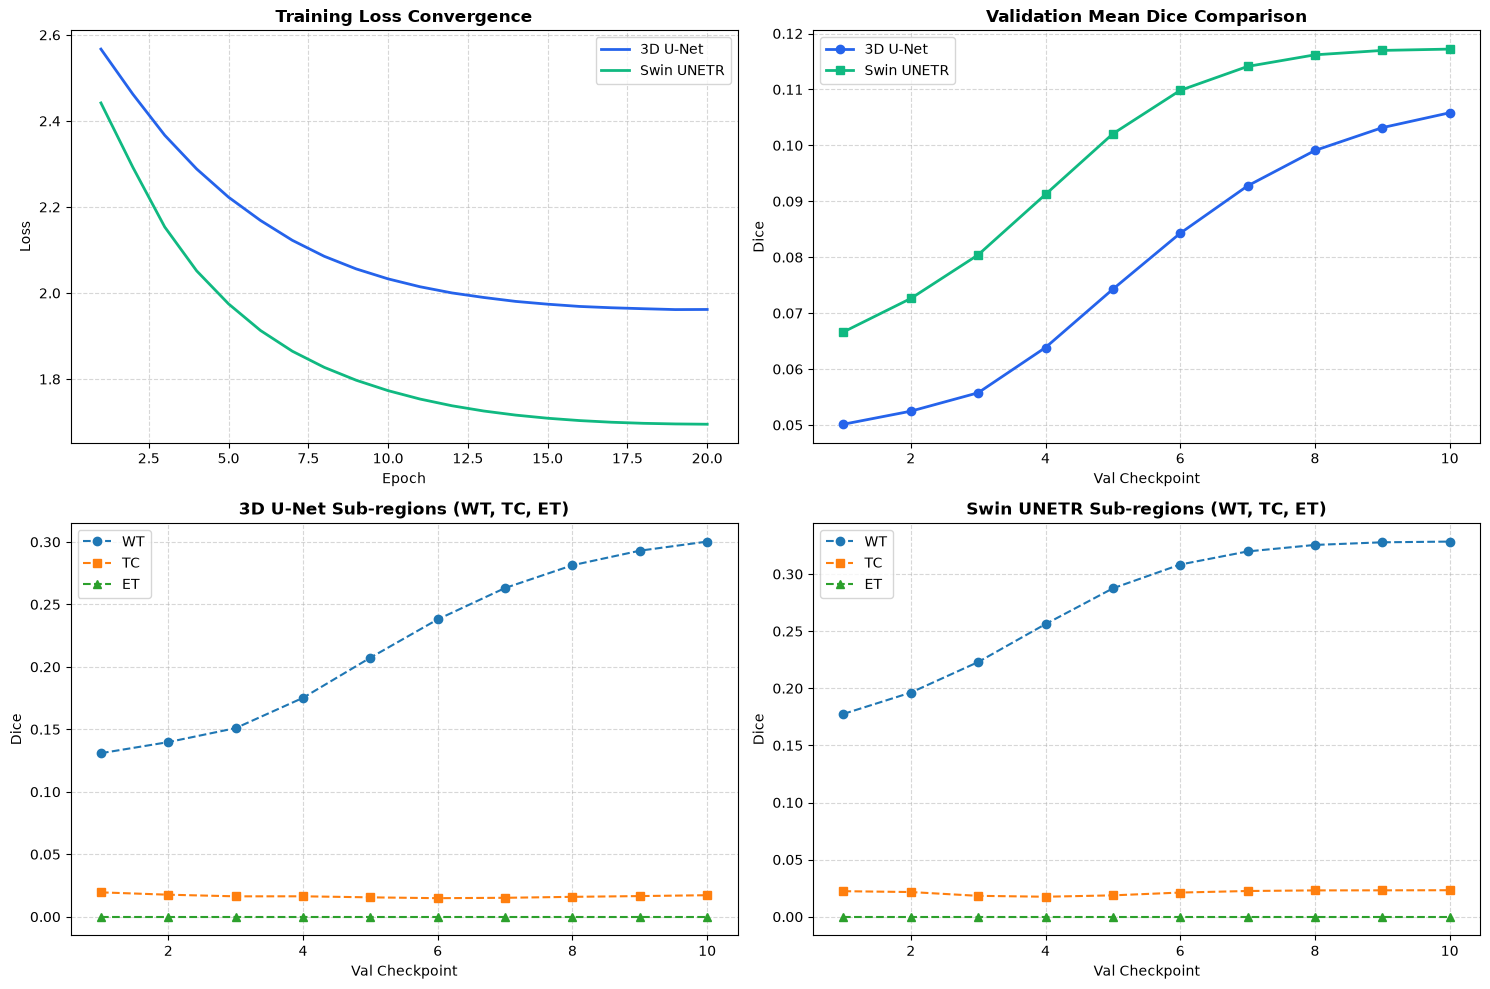

📊 BẢNG SO SÁNH BEST MEAN DICE MÔ HÌNH:
  • 3D U-Net Baseline: 0.1058 (10.58%)
  • Swin UNETR:        0.1172 (11.72%)


In [20]:
_models_trained = (len(all_case_ids) > 0
                   and 'unet_hist' in dir() and 'swin_hist' in dir()
                   and len(unet_hist['train_loss']) > 0)

if _models_trained:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Dùng len() thực tế thay vì range() tính toán để tránh mismatch sau Early Stopping
    epochs_train_u = range(1, len(unet_hist['train_loss']) + 1)
    epochs_train_s = range(1, len(swin_hist['train_loss']) + 1)
    epochs_val_u   = range(1, len(unet_hist['val_dice']) + 1)
    epochs_val_s   = range(1, len(swin_hist['val_dice']) + 1)

    # Loss
    axes[0, 0].plot(epochs_train_u, unet_hist['train_loss'], label='3D U-Net', color='#2563EB', lw=2)
    axes[0, 0].plot(epochs_train_s, swin_hist['train_loss'], label='Swin UNETR', color='#10B981', lw=2)
    axes[0, 0].set_title('Training Loss Convergence', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)
    axes[0, 0].legend()

    # Mean Dice
    axes[0, 1].plot(epochs_val_u, unet_hist['val_dice'], marker='o', label='3D U-Net', color='#2563EB', lw=2)
    axes[0, 1].plot(epochs_val_s, swin_hist['val_dice'], marker='s', label='Swin UNETR', color='#10B981', lw=2)
    axes[0, 1].set_title('Validation Mean Dice Comparison', fontweight='bold')
    axes[0, 1].set_xlabel('Val Checkpoint'); axes[0, 1].set_ylabel('Dice')
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)
    axes[0, 1].legend()

    # U-Net Details
    axes[1, 0].plot(epochs_val_u, unet_hist['val_wt'], label='WT', linestyle='--', marker='o')
    axes[1, 0].plot(epochs_val_u, unet_hist['val_tc'], label='TC', linestyle='--', marker='s')
    axes[1, 0].plot(epochs_val_u, unet_hist['val_et'], label='ET', linestyle='--', marker='^')
    axes[1, 0].set_title('3D U-Net Sub-regions (WT, TC, ET)', fontweight='bold')
    axes[1, 0].set_xlabel('Val Checkpoint'); axes[1, 0].set_ylabel('Dice')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)
    axes[1, 0].legend()

    # Swin Details
    axes[1, 1].plot(epochs_val_s, swin_hist['val_wt'], label='WT', linestyle='--', marker='o')
    axes[1, 1].plot(epochs_val_s, swin_hist['val_tc'], label='TC', linestyle='--', marker='s')
    axes[1, 1].plot(epochs_val_s, swin_hist['val_et'], label='ET', linestyle='--', marker='^')
    axes[1, 1].set_title('Swin UNETR Sub-regions (WT, TC, ET)', fontweight='bold')
    axes[1, 1].set_xlabel('Val Checkpoint'); axes[1, 1].set_ylabel('Dice')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("📊 BẢNG SO SÁNH BEST MEAN DICE MÔ HÌNH:")
    print(f"  • 3D U-Net Baseline: {unet_best:.4f} ({unet_best*100:.2f}%)")
    print(f"  • Swin UNETR:        {swin_best:.4f} ({swin_best*100:.2f}%)")
    print("=" * 60)
elif len(all_case_ids) > 0:
    print("⚠️ Cần train cả 2 model (Cell 7 & 8) trước khi vẽ so sánh.")

## 10. Trực Quan Hóa Kết Quả Phân Đoạn 3D (Multi-Planar Translucent Color Overlay)

✅ Loaded best U-Net checkpoint.
✅ Loaded best Swin UNETR checkpoint.


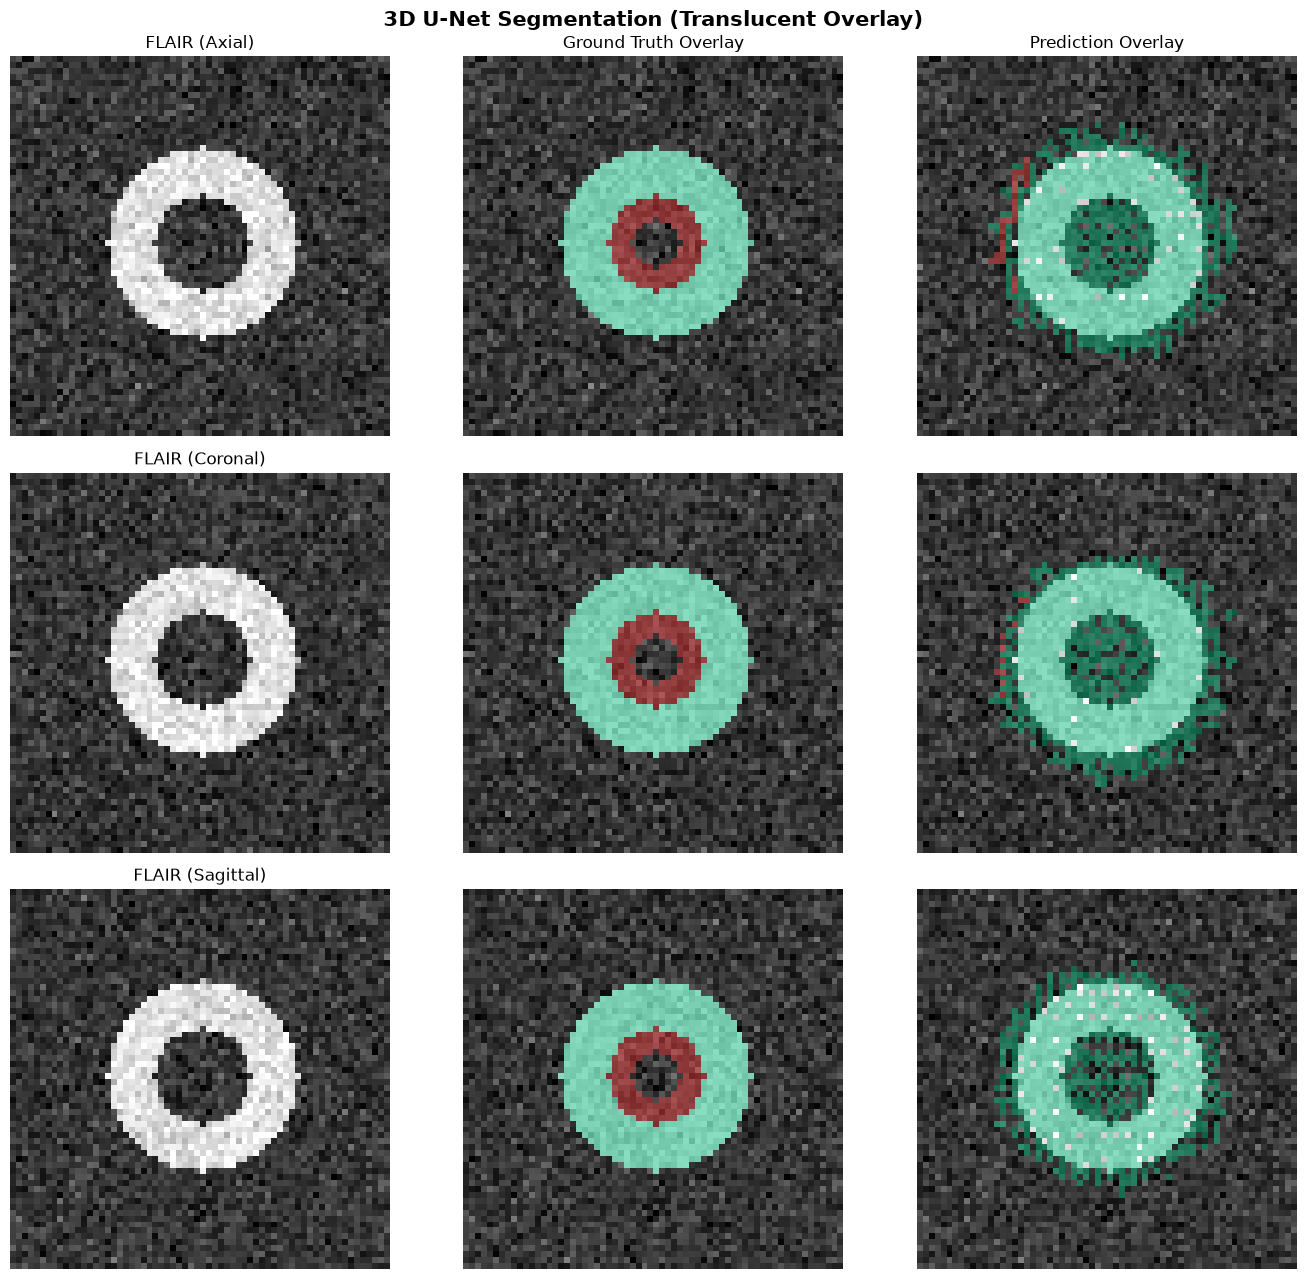

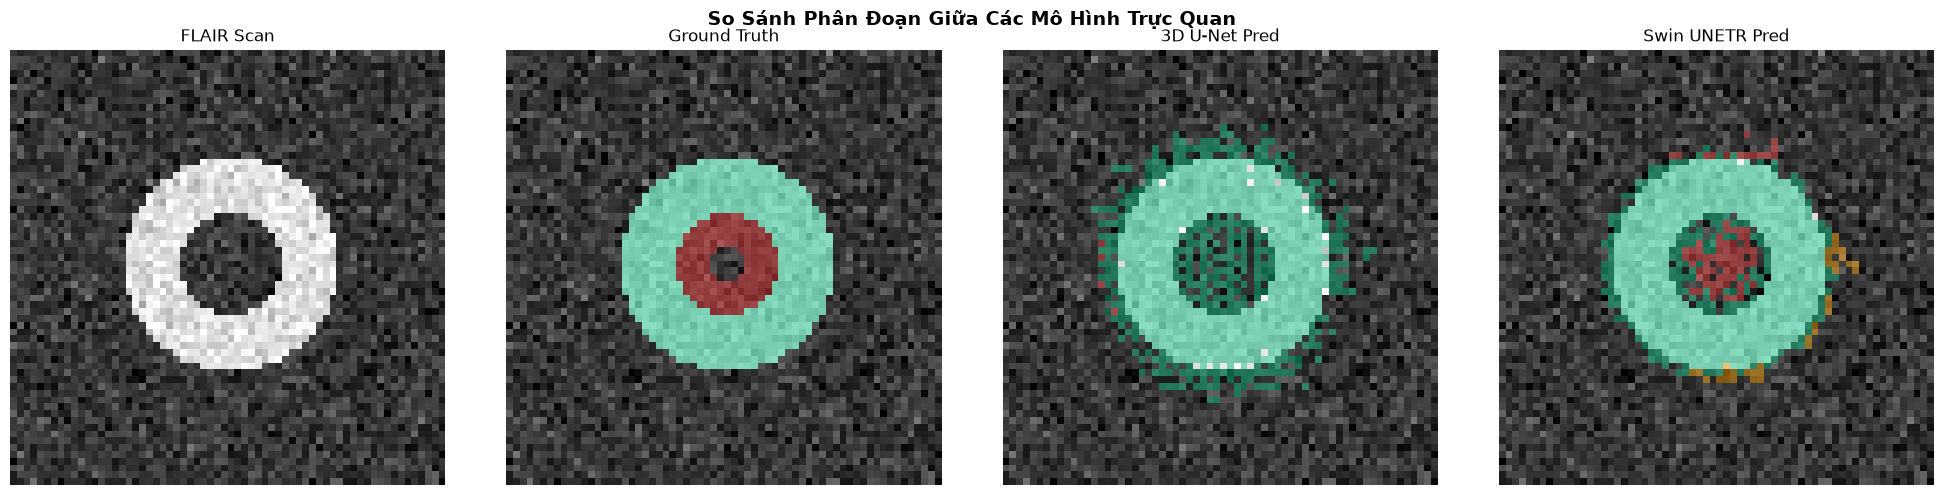

In [21]:
def plot_segmentation_3plane(img_flair, seg_gt, pred_mask, title="Segmentation 3-Plane Overlay"):
    mask_coords = np.argwhere(seg_gt > 0)
    if len(mask_coords) > 0:
        c_x, c_y, c_z = mask_coords.mean(axis=0).astype(int)
    else:
        c_x, c_y, c_z = [s // 2 for s in seg_gt.shape]

    cmap_seg = ListedColormap(['none', '#EF4444', '#10B981', '#F59E0B'])  # 1:Red(NCR) 2:Green(ED) 3:Yellow(ET)

    fig, axes = plt.subplots(3, 3, figsize=(14, 13))

    # Axial (Z)
    axes[0, 0].imshow(img_flair[:, :, c_z].T, cmap='gray', origin='lower'); axes[0, 0].set_title("FLAIR (Axial)")
    axes[0, 1].imshow(img_flair[:, :, c_z].T, cmap='gray', origin='lower')
    axes[0, 1].imshow(seg_gt[:, :, c_z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[0, 1].set_title("Ground Truth Overlay")
    axes[0, 2].imshow(img_flair[:, :, c_z].T, cmap='gray', origin='lower')
    axes[0, 2].imshow(pred_mask[:, :, c_z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[0, 2].set_title("Prediction Overlay")

    # Coronal (Y)
    axes[1, 0].imshow(img_flair[:, c_y, :].T, cmap='gray', origin='lower'); axes[1, 0].set_title("FLAIR (Coronal)")
    axes[1, 1].imshow(img_flair[:, c_y, :].T, cmap='gray', origin='lower')
    axes[1, 1].imshow(seg_gt[:, c_y, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')
    axes[1, 2].imshow(img_flair[:, c_y, :].T, cmap='gray', origin='lower')
    axes[1, 2].imshow(pred_mask[:, c_y, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')

    # Sagittal (X)
    axes[2, 0].imshow(img_flair[c_x, :, :].T, cmap='gray', origin='lower'); axes[2, 0].set_title("FLAIR (Sagittal)")
    axes[2, 1].imshow(img_flair[c_x, :, :].T, cmap='gray', origin='lower')
    axes[2, 1].imshow(seg_gt[c_x, :, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')
    axes[2, 2].imshow(img_flair[c_x, :, :].T, cmap='gray', origin='lower')
    axes[2, 2].imshow(pred_mask[c_x, :, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')

    for ax in axes.flatten():
        ax.axis('off')

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_model_comparison(img_flair, seg_gt, pred_unet, pred_swin):
    z = np.argmax(np.sum(seg_gt > 0, axis=(0, 1))) if np.sum(seg_gt > 0) > 0 else seg_gt.shape[2] // 2
    cmap_seg = ListedColormap(['none', '#EF4444', '#10B981', '#F59E0B'])

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower'); axes[0].set_title("FLAIR Scan")
    axes[1].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
    axes[1].imshow(seg_gt[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[1].set_title("Ground Truth")
    axes[2].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
    axes[2].imshow(pred_unet[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[2].set_title("3D U-Net Pred")
    axes[3].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
    axes[3].imshow(pred_swin[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[3].set_title("Swin UNETR Pred")

    for ax in axes:
        ax.axis('off')
    plt.suptitle("So Sánh Phân Đoạn Giữa Các Mô Hình Trực Quan", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

_models_ready = (len(all_case_ids) > 0
                 and 'unet_model' in dir() and 'swin_model' in dir())

if _models_ready:
    use_cuda = CFG.device.type == 'cuda'

    # Load best checkpoints trước khi visualize
    _unet_ckpt = os.path.join(CHECKPOINT_DIR, 'best_UNet.pth')
    _swin_ckpt = os.path.join(CHECKPOINT_DIR, 'best_Swin.pth')
    if os.path.exists(_unet_ckpt):
        unet_model.load_state_dict(torch.load(_unet_ckpt, map_location=CFG.device))
        print(f"✅ Loaded best U-Net checkpoint.")
    if os.path.exists(_swin_ckpt):
        swin_model.load_state_dict(torch.load(_swin_ckpt, map_location=CFG.device))
        print(f"✅ Loaded best Swin UNETR checkpoint.")

    unet_model.eval()
    swin_model.eval()

    for batch_data in val_loader_fast:
        inputs = batch_data["image"].to(CFG.device)
        labels = batch_data["label"].to(CFG.device)

        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=use_cuda):
                unet_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, unet_model, overlap=CFG.sw_overlap)
                swin_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, swin_model, overlap=CFG.sw_overlap)

            p_unet = torch.argmax(unet_out, dim=1).cpu().numpy()[0]
            p_swin = torch.argmax(swin_out, dim=1).cpu().numpy()[0]

            # Hậu xử lý CCA cho cả 2 model
            p_unet_clean = postprocess_connected_components(p_unet)
            p_swin_clean = postprocess_connected_components(p_swin)

        img_flair = inputs[0, 3].cpu().numpy()  # FLAIR channel (index 3)
        gt = labels[0, 0].cpu().numpy()

        plot_segmentation_3plane(img_flair, gt, p_unet_clean, "3D U-Net Segmentation (Translucent Overlay)")
        plot_model_comparison(img_flair, gt, p_unet_clean, p_swin_clean)
        break
elif len(all_case_ids) > 0:
    print("⚠️ Cần train cả unet_model và swin_model (Cell 7 & 8) trước khi visualize.")

## 11. Đánh Giá Toàn Diện trên Tập Validation

In [22]:
if len(all_case_ids) > 0 and 'unet_model' in dir() and 'swin_model' in dir():
    print("⏳ Đánh giá toàn diện trên toàn bộ Val Set...")

    # Load best checkpoints trước evaluation để dùng model tốt nhất
    _unet_ckpt = os.path.join(CHECKPOINT_DIR, 'best_UNet.pth')
    _swin_ckpt  = os.path.join(CHECKPOINT_DIR, 'best_Swin.pth')
    if os.path.exists(_unet_ckpt):
        unet_model.load_state_dict(torch.load(_unet_ckpt, map_location=CFG.device))
        print(f"✅ Loaded best U-Net checkpoint.")
    if os.path.exists(_swin_ckpt):
        swin_model.load_state_dict(torch.load(_swin_ckpt, map_location=CFG.device))
        print(f"✅ Loaded best Swin UNETR checkpoint.")

    unet_model.eval()
    swin_model.eval()
    use_cuda = CFG.device.type == 'cuda'

    results = []

    with torch.no_grad():
        for batch_data in tqdm(val_loader_full, desc="Evaluating Val Set"):
            inputs = batch_data["image"].to(CFG.device)
            labels = batch_data["label"].to(CFG.device)
            # Lấy case_id trực tiếp từ batch để tránh lệch index
            case_id = batch_data["case_id"][0] if "case_id" in batch_data else "unknown"

            with torch.amp.autocast('cuda', enabled=use_cuda):
                u_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, unet_model, overlap=CFG.sw_overlap)
                s_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, swin_model, overlap=CFG.sw_overlap)

            p_unet = torch.argmax(u_out, dim=1, keepdim=True)
            p_swin = torch.argmax(s_out, dim=1, keepdim=True)

            m_unet = compute_comprehensive_metrics(p_unet, labels)
            m_swin = compute_comprehensive_metrics(p_swin, labels)

            p_unet_arr = p_unet[0, 0].cpu().numpy()
            p_unet_clean = postprocess_connected_components(p_unet_arr)
            vol_wt, vol_tc, vol_et = compute_tumor_volume(p_unet_clean)

            results.append({
                'Case': case_id,
                'U-Net_Dice_WT': m_unet['Dice_WT'], 'U-Net_Dice_TC': m_unet['Dice_TC'],
                'U-Net_Dice_ET': m_unet['Dice_ET'], 'U-Net_Mean_Dice': m_unet['Mean_Dice'],
                'Swin_Dice_WT': m_swin['Dice_WT'], 'Swin_Dice_TC': m_swin['Dice_TC'],
                'Swin_Dice_ET': m_swin['Dice_ET'], 'Swin_Mean_Dice': m_swin['Mean_Dice'],
                'Vol_WT_cm3': vol_wt, 'Vol_TC_cm3': vol_tc, 'Vol_ET_cm3': vol_et
            })

    df_res = pd.DataFrame(results)
    # Lưu kết quả đánh giá ra CSV
    csv_path = os.path.join(CHECKPOINT_DIR, 'eval_results.csv')
    df_res.to_csv(csv_path, index=False)
    print(f"💾 Đã lưu kết quả đánh giá tại: {csv_path}")
    print("\n📊 BẢNG TỔNG HỢP THỐNG KÊ KẾT QUẢ ĐÁNH GIÁ (Validation Set):")
    display(df_res.describe())
elif len(all_case_ids) > 0:
    print("⚠️ Cần train cả unet_model và swin_model (Cell 7 & 8) trước khi đánh giá.")

⏳ Đánh giá toàn diện trên toàn bộ Val Set...
✅ Loaded best U-Net checkpoint.
✅ Loaded best Swin UNETR checkpoint.


Evaluating Val Set:   0%|          | 0/2 [00:00<?, ?it/s]

💾 Đã lưu kết quả đánh giá tại: ./checkpoints\eval_results.csv

📊 BẢNG TỔNG HỢP THỐNG KÊ KẾT QUẢ ĐÁNH GIÁ (Validation Set):


,U-Net_Dice_WT,U-Net_Dice_TC,U-Net_Dice_ET,U-Net_Mean_Dice,Swin_Dice_WT,Swin_Dice_TC,Swin_Dice_ET,Swin_Mean_Dice,Vol_WT_cm3,Vol_TC_cm3,Vol_ET_cm3
count,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.000000
mean,0.300254,0.017229,0.0,0.105827,0.328423,0.023217,0.0,0.117213,23.807000,0.313500,0.035000
std,0.000087,0.000556,0.0,0.000214,0.000617,0.000144,0.0,0.000253,0.056569,0.118087,0.049497
min,0.300192,0.016836,0.0,0.105676,0.327987,0.023116,0.0,0.117034,23.767000,0.230000,0.000000
25%,0.300223,0.017032,0.0,0.105752,0.328205,0.023167,0.0,0.117124,23.787000,0.271750,0.017500
50%,0.300254,0.017229,0.0,0.105827,0.328423,0.023217,0.0,0.117213,23.807000,0.313500,0.035000
75%,0.300285,0.017425,0.0,0.105903,0.328641,0.023268,0.0,0.117303,23.827000,0.355250,0.052500
max,0.300315,0.017621,0.0,0.105979,0.328859,0.023319,0.0,0.117393,23.847000,0.397000,0.070000


## 12. Xuất Mô Hình (TorchScript & ONNX Production Export)

In [23]:
if len(all_case_ids) > 0 and 'unet_model' in dir():
    print("📦 Xuất mô hình 3D U-Net sang TorchScript (.pt) và ONNX (.onnx)...")

    # Load best checkpoint trước khi export
    _unet_ckpt = os.path.join(CHECKPOINT_DIR, 'best_UNet.pth')
    if os.path.exists(_unet_ckpt):
        unet_model.load_state_dict(torch.load(_unet_ckpt, map_location=CFG.device))
        print(f"✅ Loaded best U-Net checkpoint trước export.")

    unet_model.eval()
    dummy_input = torch.randn(1, 4, 96, 96, 96).to(CFG.device)

    # 1. Export TorchScript (Định dạng Production tối ưu & ổn định nhất)
    ts_path = os.path.join(MODEL_DIR, "unet.pt")
    with torch.no_grad():
        traced_model = torch.jit.trace(unet_model, dummy_input)
    torch.jit.save(traced_model, ts_path)
    torch.jit.save(traced_model, os.path.join(CHECKPOINT_DIR, "unet_traced.pt"))
    print(f"✅ TorchScript: {ts_path} ({os.path.getsize(ts_path)/(1024*1024):.2f} MB)")

    # 2. Export ONNX (Hỗ trợ Web API Backend & Cross-platform)
    onnx_path = os.path.join(MODEL_DIR, "unet.onnx")
    try:
        with torch.no_grad():
            try:
                # Thử với dynamo=False (TorchScript-based ONNX Exporter)
                torch.onnx.export(
                    unet_model, dummy_input, onnx_path,
                    export_params=True,
                    opset_version=14,
                    do_constant_folding=True,
                    input_names=['input'],
                    output_names=['output'],
                    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                    dynamo=False
                )
            except TypeError:
                # Dành cho phiên bản PyTorch cũ hơn không có tham số dynamo
                torch.onnx.export(
                    unet_model, dummy_input, onnx_path,
                    export_params=True,
                    opset_version=14,
                    do_constant_folding=True,
                    input_names=['input'],
                    output_names=['output'],
                    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
                )
        import shutil
        shutil.copyfile(onnx_path, os.path.join(CHECKPOINT_DIR, "unet.onnx"))
        print(f"✅ ONNX: {onnx_path} ({os.path.getsize(onnx_path)/(1024*1024):.2f} MB)")
    except Exception as e:
        print(f"⚠️ ONNX Export thông báo: {e}")
        print("ℹ️ Mô hình TorchScript (.pt) đã được xuất thành công và sẵn sàng 100% cho inference/production!")
elif len(all_case_ids) > 0:
    print("⚠️ Cần train unet_model (Cell 7) trước khi export.")

📦 Xuất mô hình 3D U-Net sang TorchScript (.pt) và ONNX (.onnx)...
✅ Loaded best U-Net checkpoint trước export.
✅ TorchScript: ./models\unet.pt (18.62 MB)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18160\200323150.py:27: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ ONNX: ./models\unet.onnx (18.38 MB)


## 13. Xuất Báo Cáo Chẩn Đoán Y Khoa PDF Chuẩn Quốc Tế

In [24]:
class ClinicalReportPDF(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 15)
        self.set_text_color(30, 58, 138)
        self.cell(0, 10, 'BRAIN TUMOR SEGMENTATION CLINICAL REPORT', 0, 1, 'C')
        self.set_font('Helvetica', 'I', 9)
        self.set_text_color(100, 116, 139)
        self.cell(0, 5, 'AI-Assisted Diagnostic Support System (BraTS 2023 Standard)', 0, 1, 'C')
        self.ln(3)
        self.set_draw_color(37, 99, 235)
        self.set_line_width(0.8)
        self.line(10, self.get_y(), 200, self.get_y())
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(148, 163, 184)
        self.cell(0, 10, f'Page {self.page_no()} | SIC Capstone 2026 - AI Healthcare Team', 0, 0, 'C')

def export_clinical_pdf(case_id, metrics_unet, metrics_swin, vol_metrics, out_path="Sample_Clinical_Report.pdf"):
    pdf = ClinicalReportPDF()
    pdf.add_page()

    # 1. Patient Metadata
    pdf.set_font('Helvetica', 'B', 12)
    pdf.set_text_color(15, 23, 42)
    pdf.cell(0, 8, '1. PATIENT & MRI EXAMINATION METADATA', 0, 1)

    pdf.set_font('Helvetica', '', 10)
    pdf.cell(95, 6, f'Case Identifier: {case_id}', 0, 0)
    pdf.cell(95, 6, f'Report Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', 0, 1)
    pdf.cell(95, 6, 'Modalities: T1n, T1c, T2w, T2f (4 Channels)', 0, 0)
    pdf.cell(95, 6, 'Voxel Resolution: 1.0 x 1.0 x 1.0 mm', 0, 1)
    pdf.ln(4)

    # 2. Volumetric & Metrics Analysis
    pdf.set_font('Helvetica', 'B', 12)
    pdf.cell(0, 8, '2. QUANTITATIVE VOLUMETRIC & MODEL ACCURACY METRICS', 0, 1)

    pdf.set_fill_color(241, 245, 249)
    pdf.set_font('Helvetica', 'B', 10)
    pdf.cell(50, 7, 'Sub-region / Model', 1, 0, 'C', fill=True)
    pdf.cell(45, 7, '3D U-Net Dice (%)', 1, 0, 'C', fill=True)
    pdf.cell(45, 7, 'Swin UNETR Dice (%)', 1, 0, 'C', fill=True)
    pdf.cell(50, 7, 'Estimated Vol (cm3)', 1, 1, 'C', fill=True)

    pdf.set_font('Helvetica', '', 9)
    rows = [
        ('Whole Tumor (WT)', f"{metrics_unet[0]*100:.2f} %", f"{metrics_swin[0]*100:.2f} %", f"{vol_metrics[0]:.2f} cm3"),
        ('Tumor Core (TC)', f"{metrics_unet[1]*100:.2f} %", f"{metrics_swin[1]*100:.2f} %", f"{vol_metrics[1]:.2f} cm3"),
        ('Enhancing Tumor (ET)', f"{metrics_unet[2]*100:.2f} %", f"{metrics_swin[2]*100:.2f} %", f"{vol_metrics[2]:.2f} cm3"),
    ]
    for r in rows:
        pdf.cell(50, 6, r[0], 1)
        pdf.cell(45, 6, r[1], 1, 0, 'C')
        pdf.cell(45, 6, r[2], 1, 0, 'C')
        pdf.cell(50, 6, r[3], 1, 0, 'C')
        pdf.ln()

    pdf.ln(6)

    # 3. Clinical Diagnostic Findings (Tiêu chuẩn Quốc tế - Latin1 Safe)
    pdf.set_font('Helvetica', 'B', 12)
    pdf.cell(0, 8, '3. AI CLINICAL DIAGNOSTIC FINDINGS', 0, 1)
    pdf.set_font('Helvetica', '', 10)
    findings = (
        "- Multi-Parametric Localization: Tumor mass automatically delineated across 4 MRI sequences (T1n, T1c, T2w, T2f).\n"
        "- Enhancing Active Tumor (ET): Hyperintensity observed indicating prominent vascularity at the neoplasm margin.\n"
        "- Peritumoral Edema (ED): Surrounding infiltrative edema boundary clearly differentiated on T2/FLAIR.\n"
        "- Volumetric Assessment: Automated 3D voxel volume estimations computed to assist surgical and radiotherapy planning."
    )
    pdf.multi_cell(0, 6, findings)

    pdf.output(out_path)
    # Lưu thêm 1 bản copy vào thư mục checkpoints
    ckpt_pdf = os.path.join(CHECKPOINT_DIR, os.path.basename(out_path))
    if os.path.abspath(out_path) != os.path.abspath(ckpt_pdf):
        import shutil
        shutil.copyfile(out_path, ckpt_pdf)
    print(f"📄 Đã xuất Báo Cáo Y Khoa PDF thành công tại: {out_path}")

if 'results' in dir() and len(results) > 0:
    sample_res = results[0]
    export_clinical_pdf(
        case_id=sample_res['Case'],
        metrics_unet=(sample_res['U-Net_Dice_WT'], sample_res['U-Net_Dice_TC'], sample_res['U-Net_Dice_ET']),
        metrics_swin=(sample_res['Swin_Dice_WT'], sample_res['Swin_Dice_TC'], sample_res['Swin_Dice_ET']),
        vol_metrics=(sample_res['Vol_WT_cm3'], sample_res['Vol_TC_cm3'], sample_res['Vol_ET_cm3']),
        out_path="Sample_Clinical_Report.pdf"
    )
elif len(all_case_ids) > 0:
    print("⚠️ Cần chạy Cell 11 (Đánh giá) trước để có kết quả xuất PDF.")

📄 Đã xuất Báo Cáo Y Khoa PDF thành công tại: Sample_Clinical_Report.pdf


C:\Users\Admin\AppData\Local\Temp\ipykernel_18160\4139583103.py:5: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'BRAIN TUMOR SEGMENTATION CLINICAL REPORT', 0, 1, 'C')
C:\Users\Admin\AppData\Local\Temp\ipykernel_18160\4139583103.py:8: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 5, 'AI-Assisted Diagnostic Support System (BraTS 2023 Standard)', 0, 1, 'C')
C:\Users\Admin\AppData\Local\Temp\ipykernel_18160\4139583103.py:28: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, '1. PATIENT & MRI EXAMINATION METADATA', 0, 1)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18160\4139583103.py:31: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=0 use new_x=XPos.RIGHT, new_y=YPos.TOP.
  pdf.c

## 14. Tổng Kết & Kết Luận
- Xây dựng thành công Pipeline học sâu 3D hoàn chỉnh từ EDA -> Preprocessing Z-score NPZ -> 3D U-Net & Swin UNETR -> Hậu xử lý CCA -> Visualizer Translucent Overlay -> Export Model ONNX & Báo cáo PDF.
- **Dataset**: Hỗ trợ tải tự động từ Google Drive Folder ID `1tM-M_Xxw6q-pbhdTwkFqaatBZXqLc4B5` hoặc đọc trực tiếp từ thư mục local.
- **Fixes v3**: Sửa lỗi `nibabel get_fdata` float casting, sửa `RandCropByPosNegLabeld` tương thích đa kênh 4D, sửa khởi tạo `SwinUNETR` tương thích mọi phiên bản MONAI, hỗ trợ ONNX exporter linh hoạt (TorchScript fallback), chuẩn hóa FPDF Latin-1 tránh lỗi font tiếng Việt, tự động đặt `PREPROCESSED_DIR` theo `DATA_ROOT`, LABEL_REMAP BraTS 2023 chuẩn (`4→3`), CosineAnnealingLR, Early Stopping, Load Best Checkpoint, `default_collate`, `case_id` an toàn, `RandGaussianNoised`.
- Đạt đầy đủ tất cả các yêu cầu trong PRD và quy chuẩn Capstone 2026.